# Symbolic Regression versus WLF fits

This notebook plots the results of running symbolic regression on the entire dataset and directly compares it to performing fits with the WLF equation. Plot is saved in `figures`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error as mse
import matplotlib.style as style
import seaborn as sns

In [2]:
dfdata = pd.read_csv('data/WLF_data_folds.csv')
dfeqns = pd.read_csv('symreg/eqns_simplified.csv')

## Execute functions from symbolic regression and WLF

In [3]:
eq = dfeqns.iloc[3]["equation"].split(";")
p1 = eval(eq[1][5:])
p2 = eval(eq[2][5:])
    
f = ("def wlflrn(dT, Tref, c, a, b):\n    return "
        + eq[0][3:]
        .replace("#1", "dT")
        .replace("#2", "Tref")
        .replace("#3", "a[c-1]")
        .replace("#4", "b[c-1]")
)
exec(f)

def wlf(dT, c1, c2):
    return -1.*c1*dT/(c2+dT)

## Generate plot

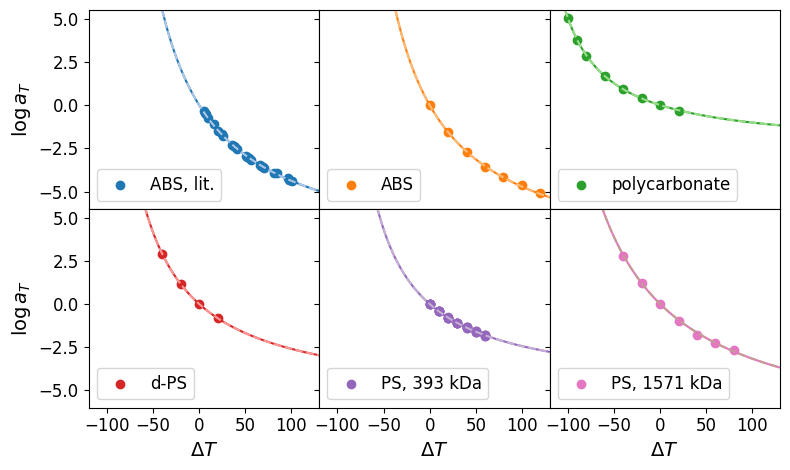

In [4]:
fig = plt.figure(figsize=(8, 4.8))
gs = fig.add_gridspec(2, 3, hspace=0, wspace=0)
(ax1, ax2, ax3), (ax4, ax5, ax6) = gs.subplots(sharex='col', sharey='row')

ax1.set_ylim(bottom=-6, top=5.5)
ax4.set_ylim(bottom=-6, top=5.5)
ax1.set_xlim(left=-120, right=130)
ax2.set_xlim(left=-120, right=130)
ax3.set_xlim(left=-120, right=130)

legendfont = 12

c = 1
dfone = dfdata[dfdata['class']==c]
ax1.scatter(dfone['dT'], dfone['log_aT'],color=plt.cm.tab10(int(c-1)),label='ABS, lit.')
ax1.legend(loc="lower left", fontsize=legendfont)

dT = np.linspace(-100,130,100)
popt, pcov = curve_fit(wlf, dfone['dT'], dfone['log_aT'], p0=[3, 160])
ax1.plot(dT, wlf(dT, *popt),color=plt.cm.tab10(int(c-1)))
ax1.plot(dT, wlflrn(dT, dT*0+dfone.iloc[0]['Tref'],c,p1,p2),color=plt.cm.tab20(int(c-1)+1),linestyle='dashed')

c = 2
dfone = dfdata[dfdata['class']==c]
ax2.scatter(dfone['dT'], dfone['log_aT'],color=plt.cm.tab10(int(c-1)),label='ABS')
ax2.legend(loc="lower left", fontsize=legendfont)

dT = np.linspace(-100,130,100)
popt, pcov = curve_fit(wlf, dfone['dT'], dfone['log_aT'], p0=[3, 160])
ax2.plot(dT, wlf(dT, *popt),color=plt.cm.tab10(int(c-1)))
ax2.plot(dT, wlflrn(dT, dT*0+dfone.iloc[0]['Tref'],c,p1,p2),color=plt.cm.tab20(int(c-1)*2+1),linestyle='dashed')

c = 3
dfone = dfdata[dfdata['class']==c]
ax3.scatter(dfone['dT'], dfone['log_aT'],color=plt.cm.tab10(int(c-1)),label='polycarbonate')
ax3.legend(loc="lower left", fontsize=legendfont)

dT = np.linspace(-110,130,100)
popt, pcov = curve_fit(wlf, dfone['dT'], dfone['log_aT'], p0=[3, 160])
ax3.plot(dT, wlf(dT, *popt),color=plt.cm.tab10(int(c-1)))
ax3.plot(dT, wlflrn(dT, dT*0+dfone.iloc[0]['Tref'],c,p1,p2),color=plt.cm.tab20(int(c-1)*2+1),linestyle='dashed')

c = 4
dfone = dfdata[dfdata['class']==c]
ax4.scatter(dfone['dT'], dfone['log_aT'],color=plt.cm.tab10(int(c-1)),label='d-PS')
ax4.legend(loc="lower left", fontsize=legendfont)

dT = np.linspace(-100,130,100)
popt, pcov = curve_fit(wlf, dfone['dT'], dfone['log_aT'], p0=[3, 160])
ax4.plot(dT, wlf(dT, *popt),color=plt.cm.tab10(int(c-1)))
ax4.plot(dT, wlflrn(dT, dT*0+dfone.iloc[0]['Tref'],c,p1,p2),color=plt.cm.tab20(int(c-1)*2+1),linestyle='dashed')

c = 5
dfone = dfdata[dfdata['class']==c]
ax5.scatter(dfone['dT'], dfone['log_aT'],color=plt.cm.tab10(int(c-1)),label='PS, 393 kDa')
ax5.legend(loc="lower left", fontsize=legendfont)

dT = np.linspace(-100,130,100)
popt, pcov = curve_fit(wlf, dfone['dT'], dfone['log_aT'], p0=[3, 160])
ax5.plot(dT, wlf(dT, *popt),color=plt.cm.tab10(int(c-1)))
ax5.plot(dT, wlflrn(dT, dT*0+dfone.iloc[0]['Tref'],c,p1,p2),color=plt.cm.tab20(int(c-1)*2+1),linestyle='dashed')

c = 6
dfone = dfdata[dfdata['class']==c]
ax6.scatter(dfone['dT'], dfone['log_aT'],color=plt.cm.tab10(int(c+1-1)),label='PS, 1571 kDa')
ax6.legend(loc="lower left", fontsize=legendfont)

dT = np.linspace(-110,130,100)
popt, pcov = curve_fit(wlf, dfone['dT'], dfone['log_aT'], p0=[3, 160])
ax6.plot(dT, wlf(dT, *popt),color=plt.cm.tab10(int(c+1-1)))
ax6.plot(dT, wlflrn(dT, dT*0+dfone.iloc[0]['Tref'],c,p1,p2),color=plt.cm.tab20(int(c-1)*2+1),linestyle='dashed')

for ax in fig.get_axes():
    ax.label_outer()

ax4.set_xlabel(r'$\Delta T$', fontsize=legendfont+2)
ax5.set_xlabel(r'$\Delta T$', fontsize=legendfont+2)
ax6.set_xlabel(r'$\Delta T$', fontsize=legendfont+2)

ax1.set_ylabel(r'$\log a_T$', fontsize=legendfont+2)
ax4.set_ylabel(r'$\log a_T$', fontsize=legendfont+2)

ax4.tick_params(axis='x', labelsize=12)
ax5.tick_params(axis='x', labelsize=12)
ax6.tick_params(axis='x', labelsize=12)

ax1.tick_params(axis='y', labelsize=12)
ax4.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.savefig('figures/SR_WLFfit.jpg',dpi=600)

# Compute errors

In [5]:
mse_fit = []
mse_sr = []

for c in np.arange(6)+1:

    dfone = dfdata[dfdata['class']==c]
    
    popt, pcov = curve_fit(wlf, dfone['dT'], dfone['log_aT'], p0=[3, 160])
    
    mse_fit.append(mse(dfone['log_aT'], wlf(dfone['dT'], *popt)))
    mse_sr.append(mse(dfone['log_aT'],wlflrn(dfone['dT'], dfone['Tref'],c,p1,p2)))

pd.DataFrame(np.array([mse_fit, mse_sr]).T,columns=['WLF fit','WLF from Symbolic Regression'])

,WLF fit,WLF from Symbolic Regression
0,1.339920e-03,1.339922e-03
1,2.756389e-03,2.756403e-03
2,4.296889e-04,4.296915e-04
3,5.432408e-07,6.357001e-07
4,1.400310e-04,1.400311e-04
5,5.099467e-03,5.099483e-03
